In [1]:
import pandas as pd

customers = pd.read_csv("olist_customers_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")

print("All datasets loaded successfully!")

FileNotFoundError: [Errno 2] No such file or directory: 'olist_customers_dataset.csv'

In [2]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\Vaishnavi J\anaconda3\Scripts
['.anaconda-navigator-post-link.bat', '.anaconda_powershell_prompt-post-link.bat', '.anaconda_prompt-post-link.bat', '.ipynb_checkpoints', '.notebook-post-link.bat', '.qt-post-link.bat', '.spyder-post-link.bat', '2to3-script.py', '2to3.exe', 'activate', 'activate.bat', 'anaconda-navigator-script.py', 'anaconda-navigator.exe', 'anaconda-project-script.py', 'anaconda-project.exe', 'anaconda-script.py', 'anaconda.exe', 'archspec-script.py', 'archspec.exe', 'automat-visualize-script.py', 'automat-visualize.exe', 'autopep8-script.py', 'autopep8.exe', 'binstar-script.py', 'binstar.exe', 'black-script.py', 'black.exe', 'blackd-script.py', 'blackd.exe', 'bokeh-script.py', 'bokeh.exe', 'cftp-script.py', 'cftp.exe', 'chardetect-script.py', 'chardetect.exe', 'ckeygen-script.py', 'ckeygen.exe', 'cognitive load and concentration .csv', 'conch-script.py', 'conch.exe', 'conda-build-script.py', 'conda-build.exe', 'conda-content-trust-script.py', 'conda-content-tr

In [2]:
import os
os.listdir("data")

['olist_customers_dataset.csv',
 'olist_orders_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_products_dataset.csv']

In [3]:
import pandas as pd

In [4]:
customers = pd.read_csv("data/olist_customers_dataset.csv")
orders = pd.read_csv("data/olist_orders_dataset.csv")
order_items = pd.read_csv("data/olist_order_items_dataset.csv")
payments = pd.read_csv("data/olist_order_payments_dataset.csv")
reviews = pd.read_csv("data/olist_order_reviews_dataset.csv")
products = pd.read_csv("data/olist_products_dataset.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [5]:
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)
print("Products:", products.shape)

Customers: (99441, 5)
Orders: (99441, 8)
Order Items: (112650, 7)
Payments: (103886, 5)
Reviews: (99224, 7)
Products: (32951, 9)


In [6]:
datasets = {
    "Customers": customers,
    "Orders": orders,
    "Order Items": order_items,
    "Payments": payments,
    "Reviews": reviews,
    "Products": products
}

for name, df in datasets.items():
    print(f"\n{name}")
    print("-" * len(name))
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))
    print()
    print(df.dtypes)


Customers
---------
Shape: (99441, 5)
Columns: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

Orders
------
Shape: (99441, 8)
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

Order Items
-----------
Shape: (112650, 7)
Columns: ['order_id', 'order_item_id', 'product_i

In [7]:
for name, df in datasets.items():
    print(f"\n{name}")
    print("-" * 30)
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    
    if missing.empty:
        print("No missing values")
    else:
        print(missing)


Customers
------------------------------
No missing values

Orders
------------------------------
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

Order Items
------------------------------
No missing values

Payments
------------------------------
No missing values

Reviews
------------------------------
review_comment_title      87656
review_comment_message    58247
dtype: int64

Products
------------------------------
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


In [8]:
date_columns = {
    "orders": [
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ],
    "order_items": ["shipping_limit_date"],
    "reviews": [
        "review_creation_date",
        "review_answer_timestamp"
    ]
}

for column in date_columns["orders"]:
    orders[column] = pd.to_datetime(orders[column], errors="coerce")

for column in date_columns["order_items"]:
    order_items[column] = pd.to_datetime(order_items[column], errors="coerce")

for column in date_columns["reviews"]:
    reviews[column] = pd.to_datetime(reviews[column], errors="coerce")

print("Date columns converted successfully!")

Date columns converted successfully!


In [9]:
print(orders.dtypes)

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [10]:
orders["delivery_time_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.days

In [11]:
orders[[
    "order_id",
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "delivery_time_days"
]].head(10)

,order_id,order_purchase_timestamp,order_delivered_customer_date,delivery_time_days
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-10 21:25:13,8.0
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-08-07 15:27:45,13.0
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08-17 18:06:29,9.0
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-12-02 00:28:42,13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02-16 18:17:02,2.0
5,a4591c265e18cb1dcee52889e2d8acc3,2017-07-09 21:57:05,2017-07-26 10:57:55,16.0
6,136cce7faa42fdb2cefd53fdc79a6098,2017-04-11 12:22:08,NaT,NaN
7,6514b8ad8028c9f2cc2374ded245783f,2017-05-16 13:10:30,2017-05-26 12:55:51,9.0
8,76c6e866289321a7c93b82b54852dc33,2017-01-23 18:29:09,2017-02-02 14:08:10,9.0
9,e69bfb5eb88e0ed6a785585b27e16dbf,2017-07-29 11:55:02,2017-08-16 17:14:30,18.0


In [12]:
orders["delivery_time_days"].describe()

count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_time_days, dtype: float64

In [13]:
print("Average delivery time:", orders["delivery_time_days"].mean())
print("Median delivery time:", orders["delivery_time_days"].median())
print("Minimum delivery time:", orders["delivery_time_days"].min())
print("Maximum delivery time:", orders["delivery_time_days"].max())

Average delivery time: 12.094085575687217
Median delivery time: 10.0
Minimum delivery time: 0.0
Maximum delivery time: 209.0


In [14]:
orders.nlargest(10, "delivery_time_days")[
    [
        "order_id",
        "order_status",
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "delivery_time_days"
    ]
]

,order_id,order_status,order_purchase_timestamp,order_delivered_customer_date,delivery_time_days
19590,ca07593549f1816d26a572e06dc1eab6,delivered,2017-02-21 23:31:27,2017-09-19 14:36:39,209.0
55619,1b3190b2dfa9d789e1f14c05b647a14a,delivered,2018-02-23 14:57:35,2018-09-19 23:24:07,208.0
61610,440d0d17af552815d15a9e41abe49359,delivered,2017-03-07 23:59:51,2017-09-19 15:12:50,195.0
38509,0f4519c5f1c541ddec9f21b3bddd533a,delivered,2017-03-09 13:26:57,2017-09-19 14:38:21,194.0
70307,2fb597c2f772eca01b1f5c561bf6cc7b,delivered,2017-03-08 18:09:02,2017-09-19 14:33:17,194.0
89130,285ab9426d6982034523a855f55a885e,delivered,2017-03-08 22:47:40,2017-09-19 14:00:04,194.0
11399,47b40429ed8cce3aee9199792275433f,delivered,2018-01-03 09:44:01,2018-07-13 20:51:31,191.0
81401,2fe324febf907e3ea3f2aa9650869fa5,delivered,2017-03-13 20:17:10,2017-09-19 17:00:07,189.0
54480,2d7561026d542c8dbd8f0daeadf67a43,delivered,2017-03-15 11:24:27,2017-09-19 14:38:18,188.0
62286,437222e3fd1b07396f1d9ba8c15fba59,delivered,2017-03-16 11:36:00,2017-09-19 16:28:58,187.0


In [15]:
long_deliveries = orders[orders["delivery_time_days"] > 30]

print("Orders delivered in more than 30 days:", len(long_deliveries))
print("Percentage of delivered orders:", 
      round(len(long_deliveries) / orders["delivery_time_days"].notna().sum() * 100, 2), "%")

Orders delivered in more than 30 days: 4118
Percentage of delivered orders: 4.27 %


In [16]:
normal_delivery = orders[
    orders["delivery_time_days"].between(0, 30)
]

print("Orders delivered within 30 days:", len(normal_delivery))
print("Average delivery time (0–30 days):", 
      round(normal_delivery["delivery_time_days"].mean(), 2))

Orders delivered within 30 days: 92358
Average delivery time (0–30 days): 10.74


In [17]:
orders["order_month"] = orders["order_purchase_timestamp"].dt.to_period("M")

In [18]:
monthly_orders = (
    orders.groupby("order_month")
    .size()
    .reset_index(name="order_count")
)

monthly_orders.head(10)

,order_month,order_count
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780
5,2017-03,2682
6,2017-04,2404
7,2017-05,3700
8,2017-06,3245
9,2017-07,4026


In [19]:
payment_by_order = (
    payments.groupby("order_id", as_index=False)["payment_value"]
    .sum()
    .rename(columns={"payment_value": "order_revenue"})
)

payment_by_order.head()

,order_id,order_revenue
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


In [20]:
orders_revenue = orders.merge(
    payment_by_order,
    on="order_id",
    how="left"
)

orders_revenue[[
    "order_id",
    "order_purchase_timestamp",
    "order_revenue"
]].head()

,order_id,order_purchase_timestamp,order_revenue
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,28.62


In [21]:
orders_revenue["order_month"] = (
    orders_revenue["order_purchase_timestamp"].dt.to_period("M")
)

monthly_revenue = (
    orders_revenue.groupby("order_month")["order_revenue"]
    .sum()
    .reset_index()
)

monthly_revenue.head(10)

,order_month,order_revenue
0,2016-09,252.24
1,2016-10,59090.48
2,2016-12,19.62
3,2017-01,138488.04
4,2017-02,291908.01
5,2017-03,449863.60
6,2017-04,417788.03
7,2017-05,592918.82
8,2017-06,511276.38
9,2017-07,592382.92


In [22]:
peak_month = monthly_revenue.loc[
    monthly_revenue["order_revenue"].idxmax()
]

print("Peak revenue month:", peak_month["order_month"])
print("Peak revenue:", round(peak_month["order_revenue"], 2))

Peak revenue month: 2017-11
Peak revenue: 1194882.8


In [23]:
lowest_month = monthly_revenue.loc[
    monthly_revenue["order_revenue"].idxmin()
]

print("Lowest revenue month:", lowest_month["order_month"])
print("Lowest revenue:", round(lowest_month["order_revenue"], 2))

Lowest revenue month: 2016-12
Lowest revenue: 19.62


In [24]:
monthly_revenue

,order_month,order_revenue
0,2016-09,252.24
1,2016-10,59090.48
2,2016-12,19.62
3,2017-01,138488.04
4,2017-02,291908.01
5,2017-03,449863.60
6,2017-04,417788.03
7,2017-05,592918.82
8,2017-06,511276.38
9,2017-07,592382.92


In [25]:
order_products = order_items.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

order_products.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim


In [26]:
category_sales = (
    order_products
    .groupby("product_category_name")
    .agg(
        total_revenue=("price", "sum"),
        total_orders=("order_id", "nunique"),
        items_sold=("order_item_id", "count")
    )
    .sort_values("total_revenue", ascending=False)
    .reset_index()
)

category_sales.head(10)

,product_category_name,total_revenue,total_orders,items_sold
0,beleza_saude,1258681.34,8836,9670
1,relogios_presentes,1205005.68,5624,5991
2,cama_mesa_banho,1036988.68,9417,11115
3,esporte_lazer,988048.97,7720,8641
4,informatica_acessorios,911954.32,6689,7827
5,moveis_decoracao,729762.49,6449,8334
6,cool_stuff,635290.85,3632,3796
7,utilidades_domesticas,632248.66,5884,6964
8,automotivo,592720.11,3897,4235
9,ferramentas_jardim,485256.46,3518,4347


In [28]:
order_items["price"].sum()

13591643.700000003

In [29]:
unique_customers = customers["customer_unique_id"].nunique()

print("Unique customers:", unique_customers)

Unique customers: 96096


In [30]:
customer_orders = orders.merge(
    customers[["customer_id", "customer_unique_id"]],
    on="customer_id",
    how="left"
)

orders_per_customer = (
    customer_orders.groupby("customer_unique_id")
    .size()
)

repeat_customers = (orders_per_customer > 1).sum()

print("Repeat customers:", repeat_customers)
print(
    "Repeat customer percentage:",
    round(repeat_customers / unique_customers * 100, 2),
    "%"
)

Repeat customers: 2997
Repeat customer percentage: 3.12 %


In [31]:
payment_analysis = (
    payments.groupby("payment_type")
    .agg(
        total_payment=("payment_value", "sum"),
        payment_count=("order_id", "count")
    )
    .sort_values("total_payment", ascending=False)
    .reset_index()
)

payment_analysis

,payment_type,total_payment,payment_count
0,credit_card,12542084.19,76795
1,boleto,2869361.27,19784
2,voucher,379436.87,5775
3,debit_card,217989.79,1529
4,not_defined,0.00,3


In [32]:
total_payment = payment_analysis["total_payment"].sum()

payment_analysis["payment_percentage"] = (
    payment_analysis["total_payment"] / total_payment * 100
).round(2)

payment_analysis

,payment_type,total_payment,payment_count,payment_percentage
0,credit_card,12542084.19,76795,78.34
1,boleto,2869361.27,19784,17.92
2,voucher,379436.87,5775,2.37
3,debit_card,217989.79,1529,1.36
4,not_defined,0.00,3,0.00


In [33]:
review_scores = (
    reviews["review_score"]
    .value_counts()
    .sort_index()
    .reset_index()
)

review_scores.columns = ["review_score", "review_count"]

review_scores

,review_score,review_count
0,1,11424
1,2,3151
2,3,8179
3,4,19142
4,5,57328


In [34]:
average_review = reviews["review_score"].mean()

print("Average review score:", round(average_review, 2))

Average review score: 4.09


In [35]:
positive_reviews = (
    reviews["review_score"].isin([4, 5]).sum()
)

total_reviews = reviews["review_score"].notna().sum()

print("Positive reviews:", positive_reviews)
print(
    "Positive review percentage:",
    round(positive_reviews / total_reviews * 100, 2),
    "%"
)

Positive reviews: 76470
Positive review percentage: 77.07 %


In [36]:
state_customers = (
    customers.groupby("customer_state")
    .agg(
        unique_customers=("customer_unique_id", "nunique"),
        customer_records=("customer_id", "count")
    )
    .sort_values("unique_customers", ascending=False)
    .reset_index()
)

state_customers.head(10)

,customer_state,unique_customers,customer_records
0,SP,40302,41746
1,RJ,12384,12852
2,MG,11259,11635
3,RS,5277,5466
4,PR,4882,5045
5,SC,3534,3637
6,BA,3277,3380
7,DF,2075,2140
8,ES,1964,2033
9,GO,1952,2020


In [38]:
customer_orders = orders.merge(
    customers[
        ["customer_id", "customer_unique_id", "customer_state"]
    ],
    on="customer_id",
    how="left"
)

In [39]:
state_sales_data = customer_orders.merge(
    payment_by_order,
    on="order_id",
    how="left"
)

state_sales = (
    state_sales_data
    .groupby("customer_state")
    .agg(
        total_revenue=("order_revenue", "sum"),
        total_orders=("order_id", "nunique"),
        unique_customers=("customer_unique_id", "nunique")
    )
    .sort_values("total_revenue", ascending=False)
    .reset_index()
)

state_sales.head(10)

,customer_state,total_revenue,total_orders,unique_customers
0,SP,5998226.96,41746,40302
1,RJ,2144379.69,12852,12384
2,MG,1872257.26,11635,11259
3,RS,890898.54,5466,5277
4,PR,811156.38,5045,4882
5,SC,623086.43,3637,3534
6,BA,616645.82,3380,3277
7,DF,355141.08,2140,2075
8,GO,350092.31,2020,1952
9,ES,325967.55,2033,1964


In [40]:
top_categories = category_sales.head(10).copy()

top_categories["total_revenue"] = (
    top_categories["total_revenue"].round(2)
)

top_categories

,product_category_name,total_revenue,total_orders,items_sold
0,beleza_saude,1258681.34,8836,9670
1,relogios_presentes,1205005.68,5624,5991
2,cama_mesa_banho,1036988.68,9417,11115
3,esporte_lazer,988048.97,7720,8641
4,informatica_acessorios,911954.32,6689,7827
5,moveis_decoracao,729762.49,6449,8334
6,cool_stuff,635290.85,3632,3796
7,utilidades_domesticas,632248.66,5884,6964
8,automotivo,592720.11,3897,4235
9,ferramentas_jardim,485256.46,3518,4347


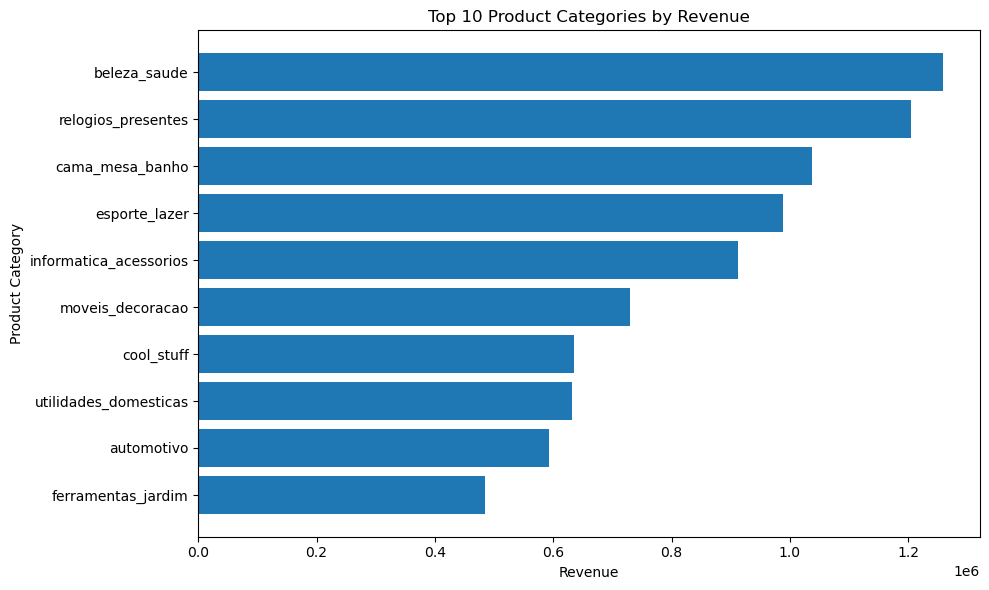

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    top_categories["product_category_name"][::-1],
    top_categories["total_revenue"][::-1]
)

plt.xlabel("Revenue")
plt.ylabel("Product Category")
plt.title("Top 10 Product Categories by Revenue")

plt.tight_layout()
plt.show()

In [42]:
order_reviews = (
    reviews.groupby("order_id", as_index=False)
    .agg(avg_review_score=("review_score", "mean"))
)

order_reviews.head()

,order_id,avg_review_score
0,00010242fe8c5a6d1ba2dd792cb16214,5.0
1,00018f77f2f0320c557190d7a144bdd3,4.0
2,000229ec398224ef6ca0657da4fc703e,5.0
3,00024acbcdf0a6daa1e931b038114c75,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0


In [43]:
delivery_reviews = orders[
    [
        "order_id",
        "delivery_time_days"
    ]
].merge(
    order_reviews,
    on="order_id",
    how="inner"
)

delivery_reviews.head()

,order_id,delivery_time_days,avg_review_score
0,e481f51cbdc54678b7cc49136f2d6af7,8.0,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,13.0,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,9.0,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,13.0,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,2.0,5.0


In [44]:
delivery_reviews["delivery_group"] = pd.cut(
    delivery_reviews["delivery_time_days"],
    bins=[-1, 7, 14, 30, float("inf")],
    labels=[
        "0-7 days",
        "8-14 days",
        "15-30 days",
        "30+ days"
    ]
)

In [45]:
delivery_review_analysis = (
    delivery_reviews
    .groupby("delivery_group", observed=True)
    .agg(
        average_review_score=("avg_review_score", "mean"),
        order_count=("order_id", "nunique")
    )
    .reset_index()
)

delivery_review_analysis["average_review_score"] = (
    delivery_review_analysis["average_review_score"].round(2)
)

delivery_review_analysis

,delivery_group,average_review_score,order_count
0,0-7 days,4.41,33541
1,8-14 days,4.29,36191
2,15-30 days,3.91,22090
3,30+ days,2.18,4008


In [46]:
delivery_review_analysis = (
    delivery_reviews
    .groupby("delivery_group", observed=True)
    .agg(
        average_review_score=("avg_review_score", "mean"),
        order_count=("order_id", "nunique")
    )
    .reset_index()
)

delivery_review_analysis["average_review_score"] = (
    delivery_review_analysis["average_review_score"].round(2)
)

delivery_review_analysis

,delivery_group,average_review_score,order_count
0,0-7 days,4.41,33541
1,8-14 days,4.29,36191
2,15-30 days,3.91,22090
3,30+ days,2.18,4008


In [47]:
orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.days

In [48]:
late_orders = orders[
    orders["delivery_delay_days"] > 0
]

on_time_orders = orders[
    orders["delivery_delay_days"] <= 0
]

print("Late orders:", len(late_orders))
print("On-time/early orders:", len(on_time_orders))

total_delivered = orders["delivery_delay_days"].notna().sum()

print(
    "Late delivery percentage:",
    round(len(late_orders) / total_delivered * 100, 2),
    "%"
)

Late orders: 6535
On-time/early orders: 89941
Late delivery percentage: 6.77 %


In [49]:
print(
    "Average delivery delay:",
    round(late_orders["delivery_delay_days"].mean(), 2),
    "days"
)

print(
    "Maximum delivery delay:",
    late_orders["delivery_delay_days"].max(),
    "days"
)

Average delivery delay: 10.62 days
Maximum delivery delay: 188.0 days


In [50]:
import sqlite3

# Create SQLite database
conn = sqlite3.connect("olist_ecommerce.db")

print("SQLite database connected successfully!")

SQLite database connected successfully!


In [52]:
orders["order_month"] = orders["order_month"].astype(str)

print("order_month converted successfully!")

order_month converted successfully!


In [53]:
customers.to_sql("customers", conn, if_exists="replace", index=False)
orders.to_sql("orders", conn, if_exists="replace", index=False)
order_items.to_sql("order_items", conn, if_exists="replace", index=False)
payments.to_sql("payments", conn, if_exists="replace", index=False)
reviews.to_sql("reviews", conn, if_exists="replace", index=False)
products.to_sql("products", conn, if_exists="replace", index=False)

print("All tables created successfully!")

All tables created successfully!


In [54]:
query = """
SELECT *
FROM orders
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)

result

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,order_month,delivery_delay_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,8.0,2017-10,-8.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,13.0,2018-07,-6.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,9.0,2018-08,-18.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,13.0,2017-11,-13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,2.0,2018-02,-10.0
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00,16.0,2017-07,-6.0
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,None,None,2017-05-09 00:00:00,NaN,2017-04,NaN
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07 00:00:00,9.0,2017-05,-12.0
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06 00:00:00,9.0,2017-01,-32.0
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00,18.0,2017-07,-7.0


In [55]:
query = """
SELECT 
    order_status,
    COUNT(*) AS order_count
FROM orders
GROUP BY order_status
ORDER BY order_count DESC;
"""

result = pd.read_sql_query(query, conn)

result

,order_status,order_count
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


In [56]:
query = """
SELECT 
    order_status,
    COUNT(*) AS order_count
FROM orders
GROUP BY order_status
ORDER BY order_count DESC;
"""

result = pd.read_sql_query(query, conn)

result

,order_status,order_count
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


In [57]:
query = """
SELECT
    c.customer_state,
    COUNT(o.order_id) AS order_count
FROM orders AS o
JOIN customers AS c
    ON o.customer_id = c.customer_id
GROUP BY c.customer_state
ORDER BY order_count DESC;
"""

result = pd.read_sql_query(query, conn)

result

,customer_state,order_count
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


In [58]:
query = """
SELECT
    c.customer_state,
    ROUND(SUM(p.payment_value), 2) AS total_revenue
FROM orders AS o
JOIN customers AS c
    ON o.customer_id = c.customer_id
JOIN payments AS p
    ON o.order_id = p.order_id
GROUP BY c.customer_state
ORDER BY total_revenue DESC;
"""

result = pd.read_sql_query(query, conn)

result

,customer_state,total_revenue
0,SP,5998226.96
1,RJ,2144379.69
2,MG,1872257.26
3,RS,890898.54
4,PR,811156.38
5,SC,623086.43
6,BA,616645.82
7,DF,355141.08
8,GO,350092.31
9,ES,325967.55


In [59]:
query = """
SELECT
    strftime('%Y-%m', order_purchase_timestamp) AS order_month,
    ROUND(SUM(p.payment_value), 2) AS monthly_revenue
FROM orders AS o
JOIN payments AS p
    ON o.order_id = p.order_id
GROUP BY order_month
ORDER BY order_month;
"""

result = pd.read_sql_query(query, conn)

result

,order_month,monthly_revenue
0,2016-09,252.24
1,2016-10,59090.48
2,2016-12,19.62
3,2017-01,138488.04
4,2017-02,291908.01
5,2017-03,449863.60
6,2017-04,417788.03
7,2017-05,592918.82
8,2017-06,511276.38
9,2017-07,592382.92


In [60]:
query = """
SELECT
    p.product_category_name,
    ROUND(SUM(oi.price), 2) AS total_revenue,
    COUNT(oi.order_item_id) AS items_sold
FROM order_items AS oi
JOIN products AS p
    ON oi.product_id = p.product_id
GROUP BY p.product_category_name
ORDER BY total_revenue DESC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)

result

,product_category_name,total_revenue,items_sold
0,beleza_saude,1258681.34,9670
1,relogios_presentes,1205005.68,5991
2,cama_mesa_banho,1036988.68,11115
3,esporte_lazer,988048.97,8641
4,informatica_acessorios,911954.32,7827
5,moveis_decoracao,729762.49,8334
6,cool_stuff,635290.85,3796
7,utilidades_domesticas,632248.66,6964
8,automotivo,592720.11,4235
9,ferramentas_jardim,485256.46,4347


In [61]:
query = """
SELECT
    c.customer_unique_id,
    COUNT(o.order_id) AS order_count
FROM customers AS c
JOIN orders AS o
    ON c.customer_id = o.customer_id
GROUP BY c.customer_unique_id
HAVING COUNT(o.order_id) > 1
ORDER BY order_count DESC;
"""

result = pd.read_sql_query(query, conn)

print("Repeat customers:", len(result))
print("\nTop repeat customers:")
result.head(10)

Repeat customers: 2997

Top repeat customers:


,customer_unique_id,order_count
0,8d50f5eadf50201ccdcedfb9e2ac8455,17
1,3e43e6105506432c953e165fb2acf44c,9
2,ca77025e7201e3b30c44b472ff346268,7
3,6469f99c1f9dfae7733b25662e7f1782,7
4,1b6c7548a2a1f9037c1fd3ddfed95f33,7
5,f0e310a6839dce9de1638e0fe5ab282a,6
6,de34b16117594161a6a89c50b289d35a,6
7,dc813062e0fc23409cd255f7f53c7074,6
8,63cfc61cee11cbe306bff5857d00bfe4,6
9,47c1a3033b8b77b3ab6e109eb4d5fdf3,6


In [62]:
query = """
WITH customer_order_counts AS (
    SELECT
        c.customer_unique_id,
        COUNT(o.order_id) AS order_count
    FROM customers AS c
    JOIN orders AS o
        ON c.customer_id = o.customer_id
    GROUP BY c.customer_unique_id
)

SELECT
    COUNT(*) AS unique_customers,
    SUM(CASE WHEN order_count > 1 THEN 1 ELSE 0 END) AS repeat_customers,
    ROUND(
        SUM(CASE WHEN order_count > 1 THEN 1 ELSE 0 END) * 100.0
        / COUNT(*),
        2
    ) AS repeat_customer_percentage
FROM customer_order_counts;
"""

result = pd.read_sql_query(query, conn)

result

,unique_customers,repeat_customers,repeat_customer_percentage
0,96096,2997,3.12


In [63]:
query = """
SELECT
    payment_type,
    COUNT(*) AS payment_count,
    ROUND(SUM(payment_value), 2) AS total_payment
FROM payments
GROUP BY payment_type
ORDER BY total_payment DESC;
"""

result = pd.read_sql_query(query, conn)

result

,payment_type,payment_count,total_payment
0,credit_card,76795,12542084.19
1,boleto,19784,2869361.27
2,voucher,5775,379436.87
3,debit_card,1529,217989.79
4,not_defined,3,0.00


In [64]:
query = """
SELECT
    review_score,
    COUNT(*) AS review_count
FROM reviews
GROUP BY review_score
ORDER BY review_score;
"""

result = pd.read_sql_query(query, conn)

result

,review_score,review_count
0,1,11424
1,2,3151
2,3,8179
3,4,19142
4,5,57328


In [65]:
query = """
SELECT
    ROUND(AVG(review_score), 2) AS average_review_score,
    SUM(CASE WHEN review_score >= 4 THEN 1 ELSE 0 END) AS positive_reviews,
    COUNT(*) AS total_reviews,
    ROUND(
        SUM(CASE WHEN review_score >= 4 THEN 1 ELSE 0 END) * 100.0
        / COUNT(*),
        2
    ) AS positive_review_percentage
FROM reviews;
"""

result = pd.read_sql_query(query, conn)

result

,average_review_score,positive_reviews,total_reviews,positive_review_percentage
0,4.09,76470,99224,77.07


In [66]:
query = """
SELECT
    CASE
        WHEN o.delivery_time_days <= 7 THEN '0-7 days'
        WHEN o.delivery_time_days <= 14 THEN '8-14 days'
        WHEN o.delivery_time_days <= 30 THEN '15-30 days'
        ELSE '30+ days'
    END AS delivery_group,
    ROUND(AVG(r.review_score), 2) AS average_review_score,
    COUNT(DISTINCT o.order_id) AS order_count
FROM orders AS o
JOIN reviews AS r
    ON o.order_id = r.order_id
WHERE o.delivery_time_days IS NOT NULL
GROUP BY delivery_group
ORDER BY
    CASE delivery_group
        WHEN '0-7 days' THEN 1
        WHEN '8-14 days' THEN 2
        WHEN '15-30 days' THEN 3
        WHEN '30+ days' THEN 4
    END;
"""

result = pd.read_sql_query(query, conn)

result

,delivery_group,average_review_score,order_count
0,0-7 days,4.41,33541
1,8-14 days,4.29,36191
2,15-30 days,3.91,22090
3,30+ days,2.18,4008
